#Import and load data

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings("ignore")

# ── Plot styling ──────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"]      = 120
plt.rcParams["figure.figsize"]  = (10, 6)
plt.rcParams["font.size"]       = 11

# ── Load cleaned data ─────────────────────────────────────
df = pd.read_csv("../data/heart_cleaned.csv")

# ── Make sure screenshots folder exists ───────────────────
os.makedirs("../screenshots", exist_ok=True)

print("✅ EDA setup complete!")
print(f"   Dataset shape : {df.shape}")
print(f"   Columns       : {list(df.columns)}")

✅ EDA setup complete!
   Dataset shape : (303, 14)
   Columns       : ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


 #Dataset Info & Missing Values

In [13]:
print("=" * 55)
print("  DATASET INFORMATION")
print("=" * 55)

# Data types and non-null counts
print("\n📋 Column Info:")
print(f"  {'Column':<12} {'Type':<12} {'Non-Null':<10} {'Unique'}")
print("  " + "-" * 45)
for col in df.columns:
    print(
        f"  {col:<12} "
        f"{str(df[col].dtype):<12} "
        f"{df[col].notna().sum():<10} "
        f"{df[col].nunique()}"
    )

print(f"\n📊 Missing Values : {df.isnull().sum().sum()}")
print(f"📊 Duplicate Rows : {df.duplicated().sum()}")

print("\n📈 Basic Statistics:")
display(df.describe().round(2))

  DATASET INFORMATION

📋 Column Info:
  Column       Type         Non-Null   Unique
  ---------------------------------------------
  age          float64      303        41
  sex          float64      303        2
  cp           float64      303        4
  trestbps     float64      303        50
  chol         float64      303        152
  fbs          float64      303        2
  restecg      float64      303        3
  thalach      float64      303        91
  exang        float64      303        2
  oldpeak      float64      303        40
  slope        float64      303        3
  ca           float64      303        4
  thal         float64      303        3
  target       int64        303        2

📊 Missing Values : 0
📊 Duplicate Rows : 0

📈 Basic Statistics:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00
mean,54.44,0.68,3.16,131.69,246.69,0.15,0.99,149.61,0.33,1.04,1.60,0.66,4.72,0.46
std,9.04,0.47,0.96,17.60,51.78,0.36,0.99,22.88,0.47,1.16,0.62,0.93,1.94,0.50
min,29.00,0.00,1.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,1.00,0.00,3.00,0.00
25%,48.00,0.00,3.00,120.00,211.00,0.00,0.00,133.50,0.00,0.00,1.00,0.00,3.00,0.00
50%,56.00,1.00,3.00,130.00,241.00,0.00,1.00,153.00,0.00,0.80,2.00,0.00,3.00,0.00
75%,61.00,1.00,4.00,140.00,275.00,0.00,2.00,166.00,1.00,1.60,2.00,1.00,7.00,1.00
max,77.00,1.00,4.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,3.00,3.00,7.00,1.00


#Class Balance Chart

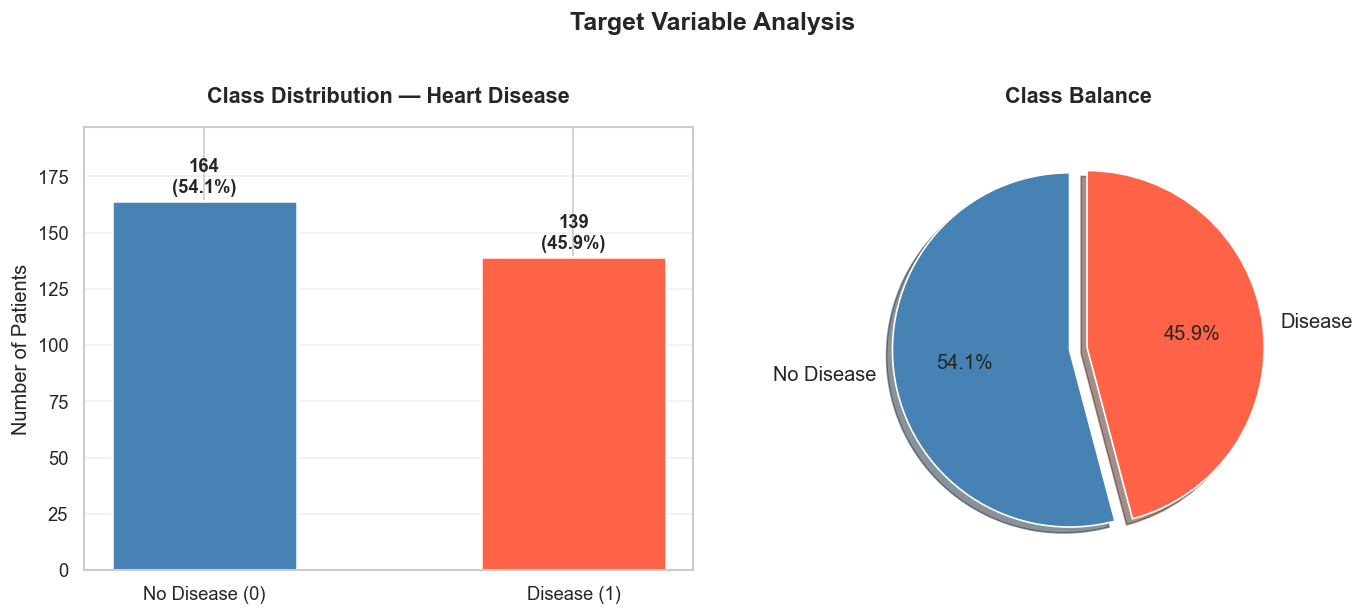

✅ Saved → screenshots/01_class_balance.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ── Bar chart ─────────────────────────────────────────────
counts = df["target"].value_counts().sort_index()
colors = ["steelblue", "tomato"]
bars   = axes[0].bar(
    ["No Disease (0)", "Disease (1)"],
    counts.values,
    color=colors,
    edgecolor="white",
    linewidth=1.5,
    width=0.5
)

# Add count + percentage labels on bars
for bar, count in zip(bars, counts.values):
    pct = count / len(df) * 100
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2,
        f"{count}\n({pct:.1f}%)",
        ha="center", va="bottom",
        fontweight="bold", fontsize=11
    )

axes[0].set_title(
    "Class Distribution — Heart Disease",
    fontsize=13, fontweight="bold", pad=15
)
axes[0].set_ylabel("Number of Patients")
axes[0].set_ylim(0, max(counts.values) * 1.2)
axes[0].grid(axis="y", alpha=0.3)

# ── Pie chart ─────────────────────────────────────────────
axes[1].pie(
    counts.values,
    labels=["No Disease", "Disease"],
    colors=colors,
    autopct="%1.1f%%",
    startangle=90,
    explode=(0.05, 0.05),
    shadow=True,
    textprops={"fontsize": 12}
)
axes[1].set_title(
    "Class Balance",
    fontsize=13, fontweight="bold", pad=15
)

plt.suptitle(
    "Target Variable Analysis",
    fontsize=15, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig(
    "../screenshots/01_class_balance.png",
    bbox_inches="tight", dpi=150
)
plt.show()
print("✅ Saved → screenshots/01_class_balance.png")

#Numerical Feature Distributions

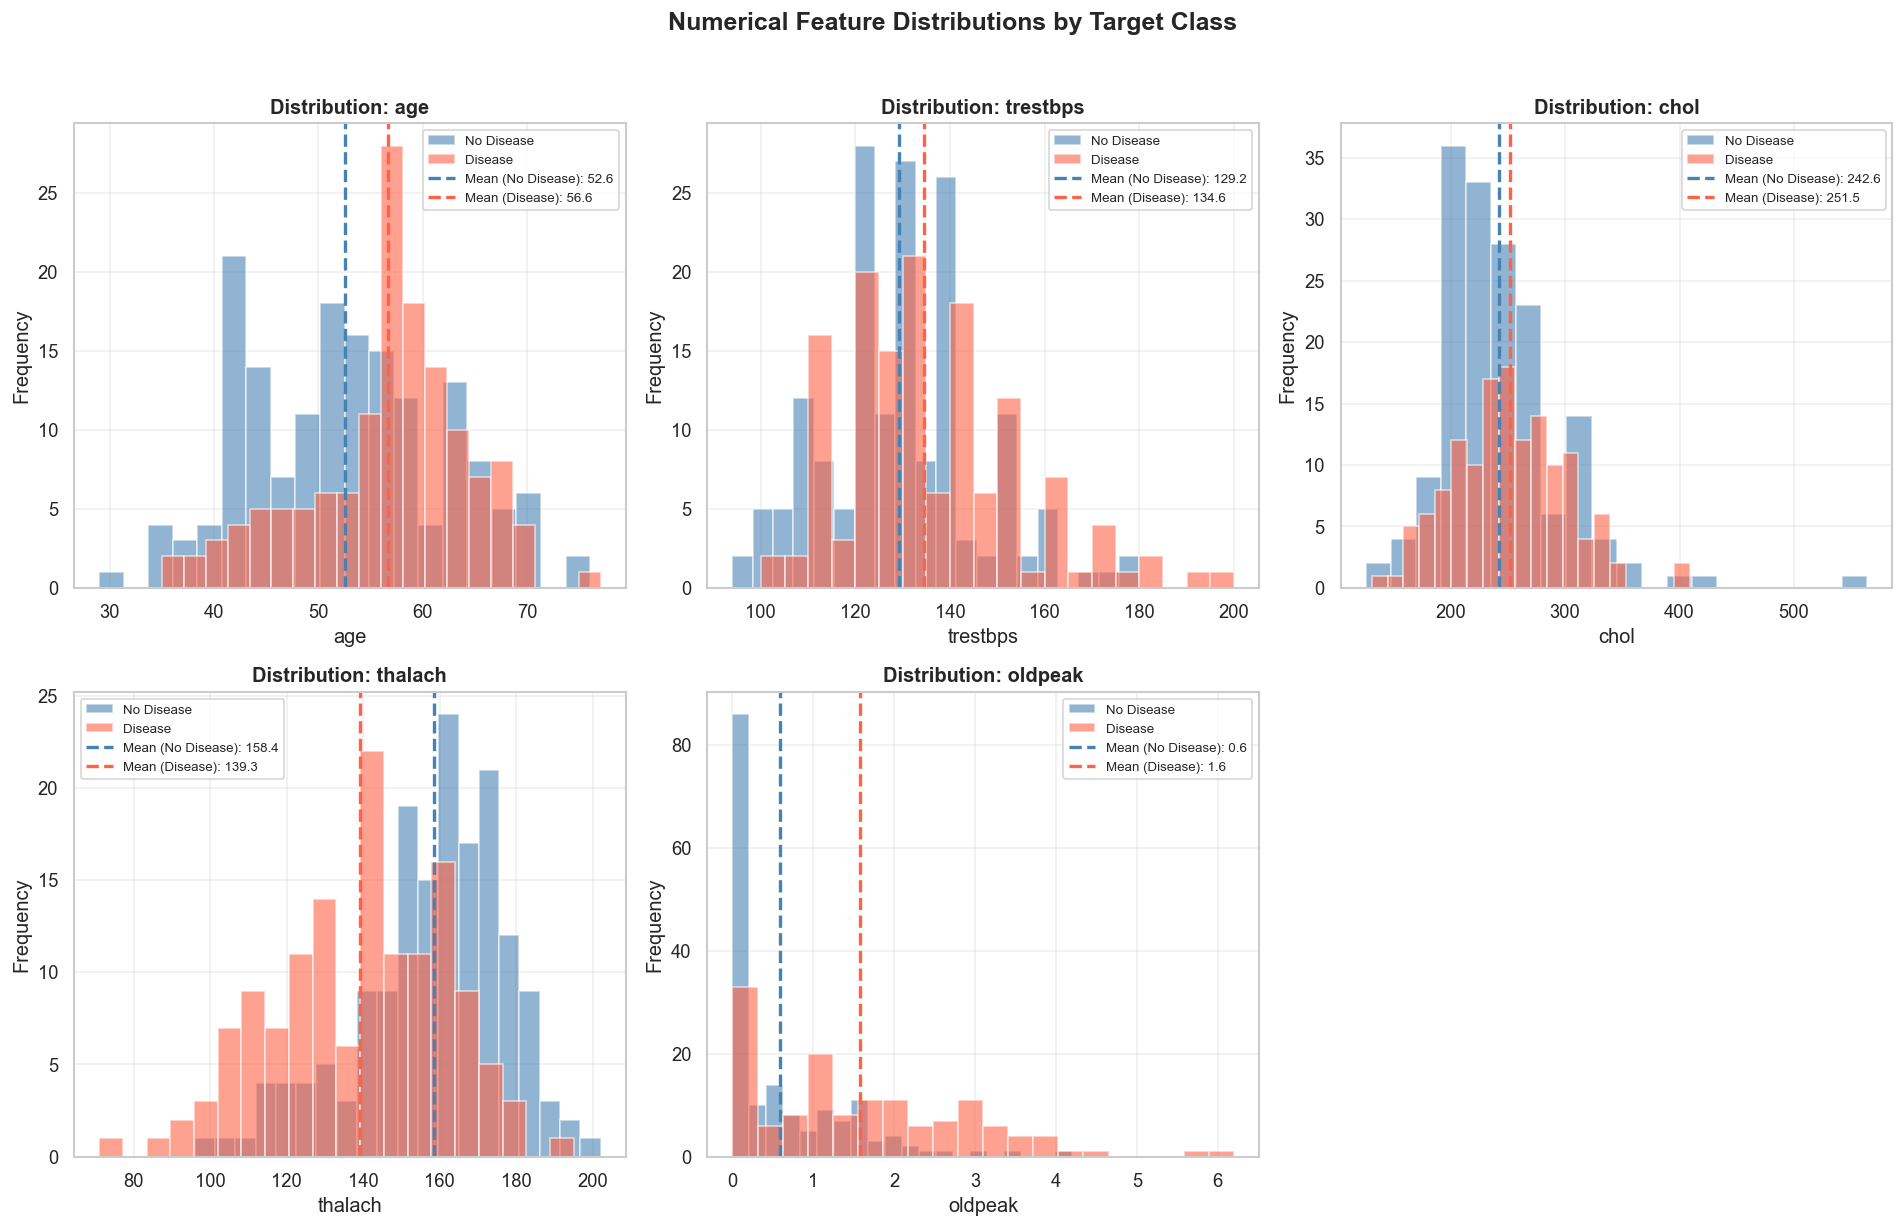

✅ Saved → screenshots/02_numerical_distributions.png


In [15]:
numerical_cols = ["age", "trestbps", "chol", "thalach", "oldpeak"]
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    # Histogram for each class
    axes[i].hist(
        df[df["target"] == 0][col],
        bins=20, alpha=0.6,
        color="steelblue", label="No Disease",
        edgecolor="white"
    )
    axes[i].hist(
        df[df["target"] == 1][col],
        bins=20, alpha=0.6,
        color="tomato", label="Disease",
        edgecolor="white"
    )

    # Mean lines
    mean_0 = df[df["target"] == 0][col].mean()
    mean_1 = df[df["target"] == 1][col].mean()
    axes[i].axvline(
        mean_0, color="steelblue",
        linestyle="--", linewidth=2,
        label=f"Mean (No Disease): {mean_0:.1f}"
    )
    axes[i].axvline(
        mean_1, color="tomato",
        linestyle="--", linewidth=2,
        label=f"Mean (Disease): {mean_1:.1f}"
    )

    axes[i].set_title(
        f"Distribution: {col}",
        fontsize=12, fontweight="bold"
    )
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")
    axes[i].legend(fontsize=8)
    axes[i].grid(alpha=0.3)

# Hide the 6th subplot (we only have 5 features)
axes[-1].set_visible(False)

plt.suptitle(
    "Numerical Feature Distributions by Target Class",
    fontsize=15, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig(
    "../screenshots/02_numerical_distributions.png",
    bbox_inches="tight", dpi=150
)
plt.show()
print("✅ Saved → screenshots/02_numerical_distributions.png")

#Categorical Feature Analysis

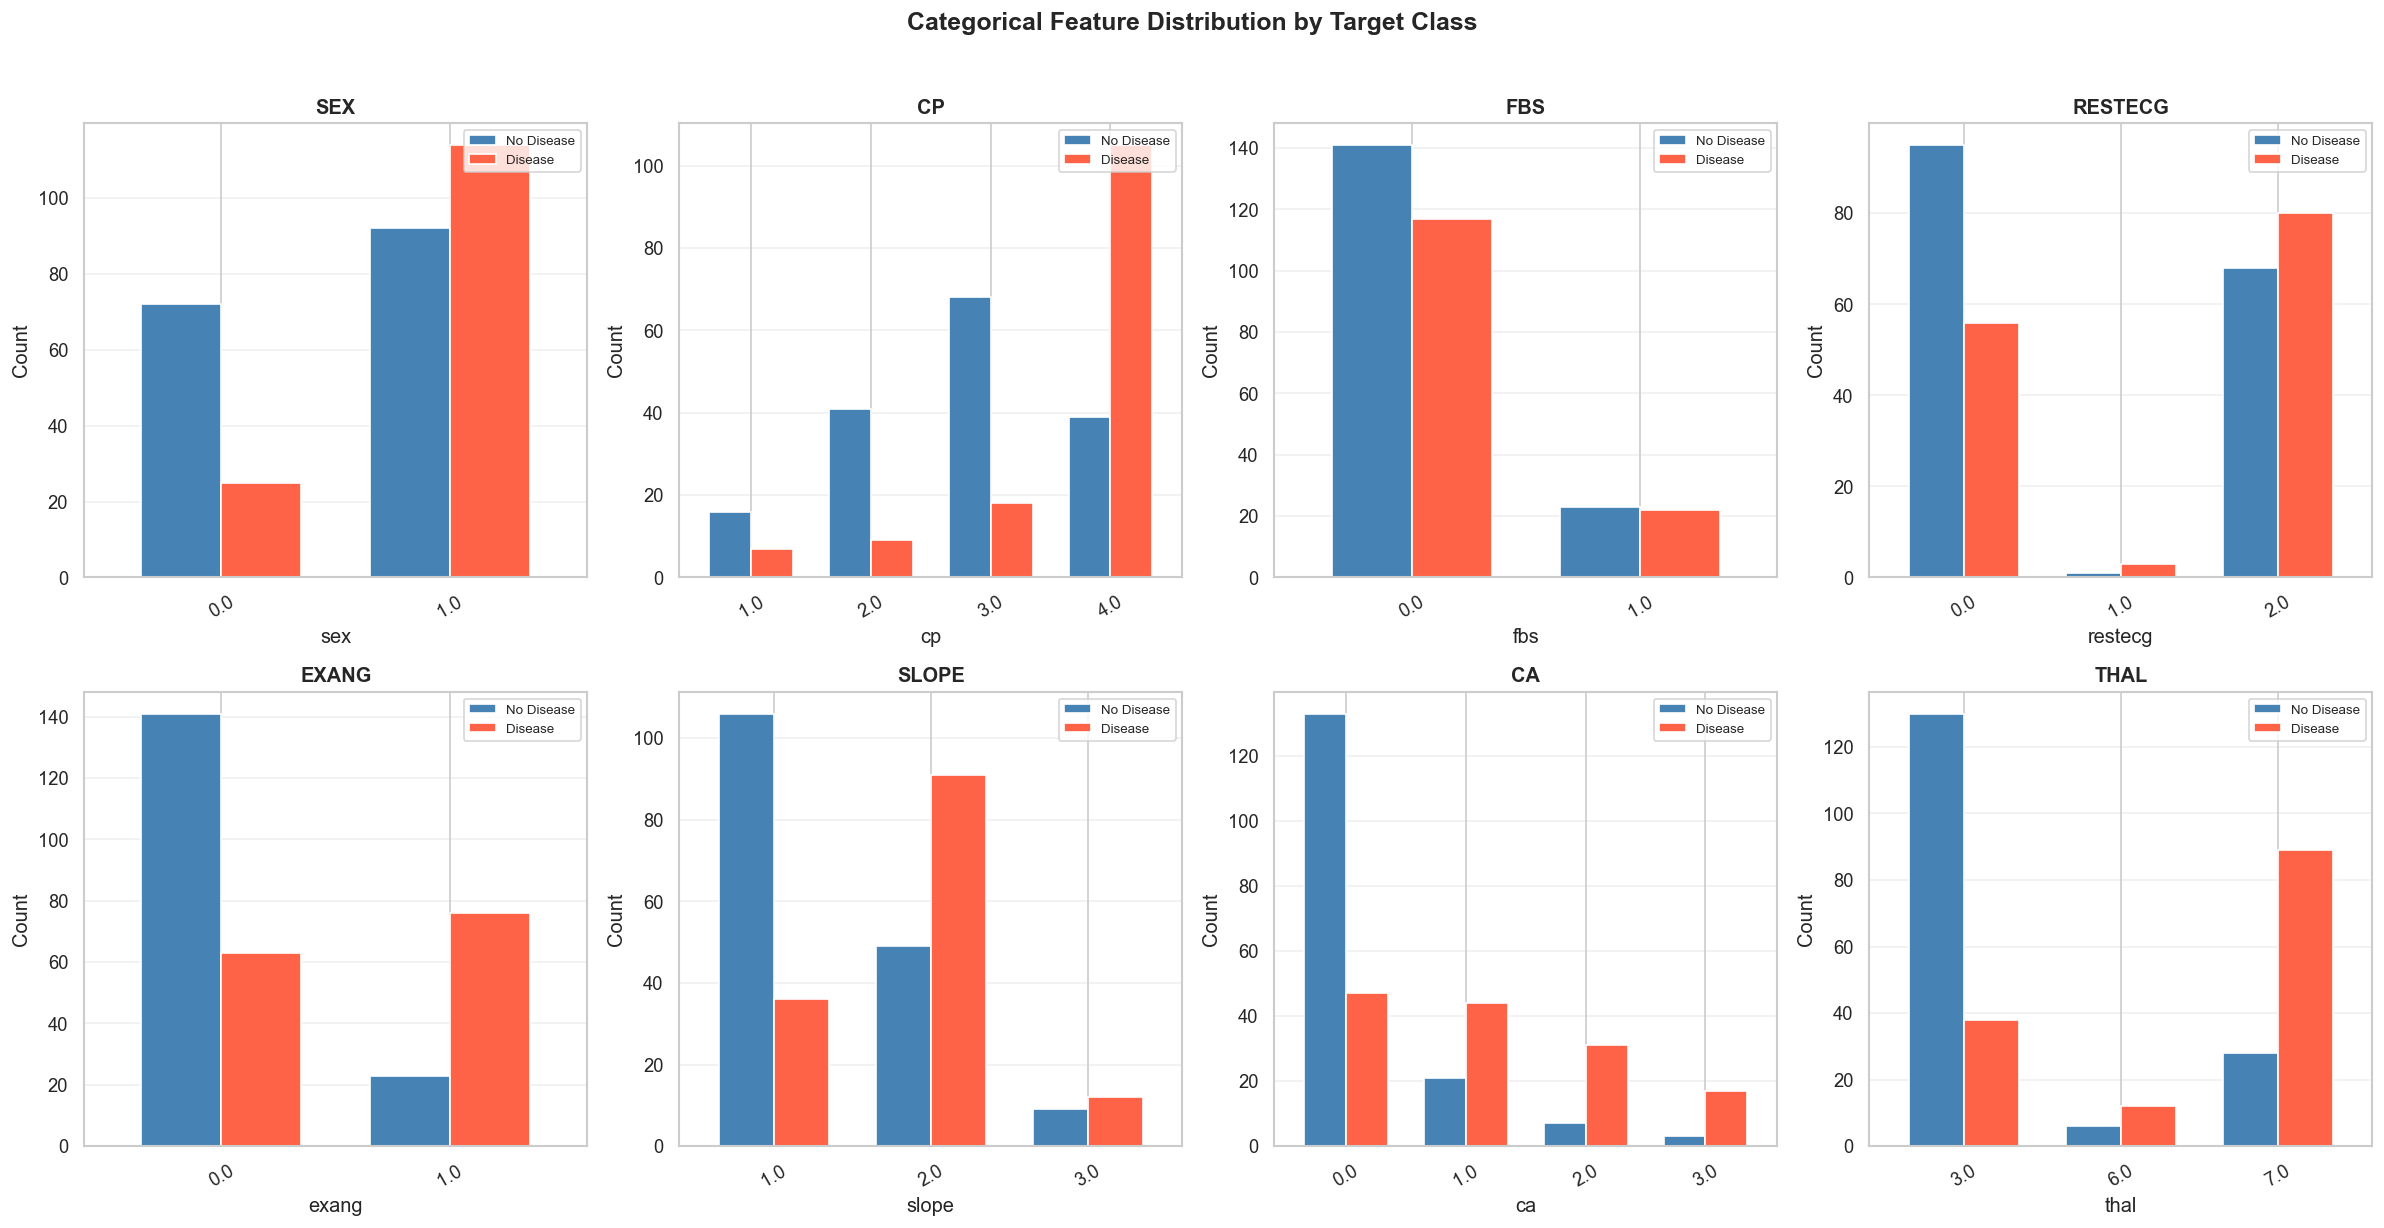

✅ Saved → screenshots/03_categorical_distributions.png


In [16]:
categorical_cols = ["sex", "cp", "fbs", "restecg",
                    "exang", "slope", "ca", "thal"]

# Readable labels for each feature
col_labels = {
    "sex"     : {0: "Female", 1: "Male"},
    "cp"      : {0: "Typical", 1: "Atypical",
                 2: "Non-anginal", 3: "Asymptomatic"},
    "fbs"     : {0: "≤120 mg/dl", 1: ">120 mg/dl"},
    "restecg" : {0: "Normal", 1: "ST-T abnormal",
                 2: "LV hypertrophy"},
    "exang"   : {0: "No", 1: "Yes"},
    "slope"   : {0: "Upsloping", 1: "Flat",
                 2: "Downsloping"},
    "ca"      : {0: "0", 1: "1", 2: "2", 3: "3"},
    "thal"    : {1: "Normal", 2: "Fixed", 3: "Reversible"},
}

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    # Count plot grouped by target
    data_grouped = df.groupby([col, "target"]).size().unstack(fill_value=0)

    data_grouped.plot(
        kind="bar",
        ax=axes[i],
        color=["steelblue", "tomato"],
        edgecolor="white",
        width=0.7
    )

    axes[i].set_title(
        f"{col.upper()}",
        fontsize=12, fontweight="bold"
    )
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
    axes[i].legend(
        ["No Disease", "Disease"],
        fontsize=8, loc="upper right"
    )
    axes[i].tick_params(axis="x", rotation=30)
    axes[i].grid(axis="y", alpha=0.3)

plt.suptitle(
    "Categorical Feature Distribution by Target Class",
    fontsize=15, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig(
    "../screenshots/03_categorical_distributions.png",
    bbox_inches="tight", dpi=150
)
plt.show()
print("✅ Saved → screenshots/03_categorical_distributions.png")

#Correlation Heatmap

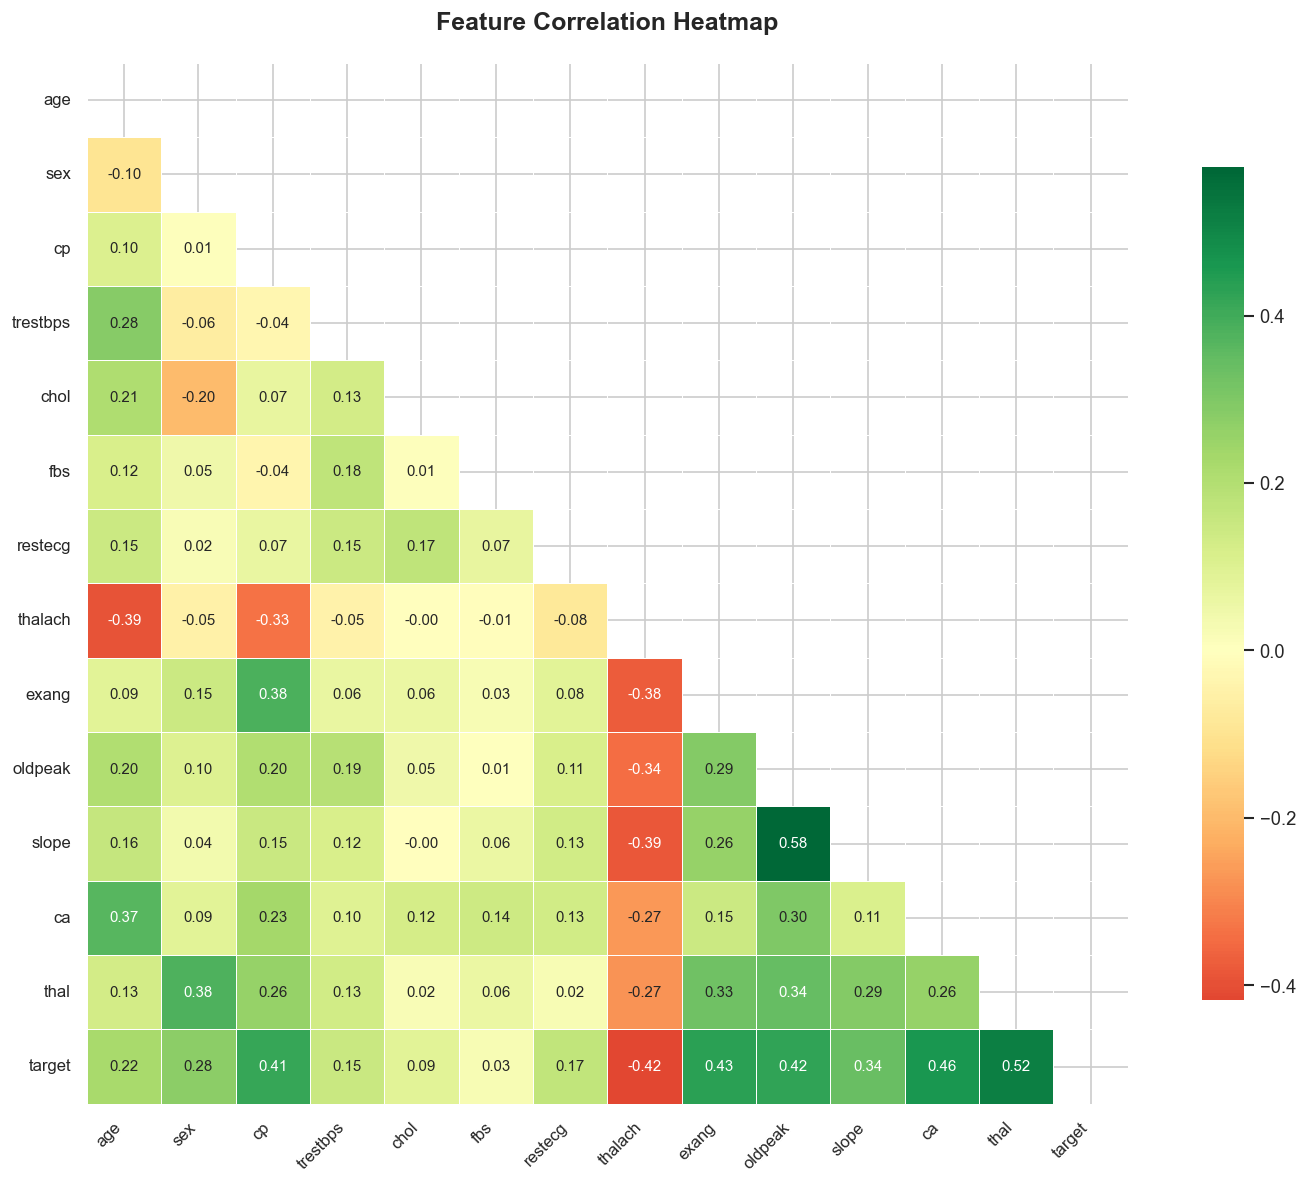

✅ Saved → screenshots/04_correlation_heatmap.png


In [17]:
fig, ax = plt.subplots(figsize=(13, 10))

# Compute correlation matrix
corr = df.corr()

# Mask upper triangle for cleaner look
mask = np.triu(np.ones_like(corr, dtype=bool))

# Draw heatmap
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0,
    square=True,
    linewidths=0.5,
    linecolor="white",
    ax=ax,
    annot_kws={"size": 9},
    cbar_kws={"shrink": 0.8}
)

ax.set_title(
    "Feature Correlation Heatmap",
    fontsize=15, fontweight="bold", pad=20
)

# Rotate axis labels
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45, ha="right", fontsize=10
)
ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0, fontsize=10
)

plt.tight_layout()
plt.savefig(
    "../screenshots/04_correlation_heatmap.png",
    bbox_inches="tight", dpi=150
)
plt.show()
print("✅ Saved → screenshots/04_correlation_heatmap.png")

#Boxplots (Outlier Detection)

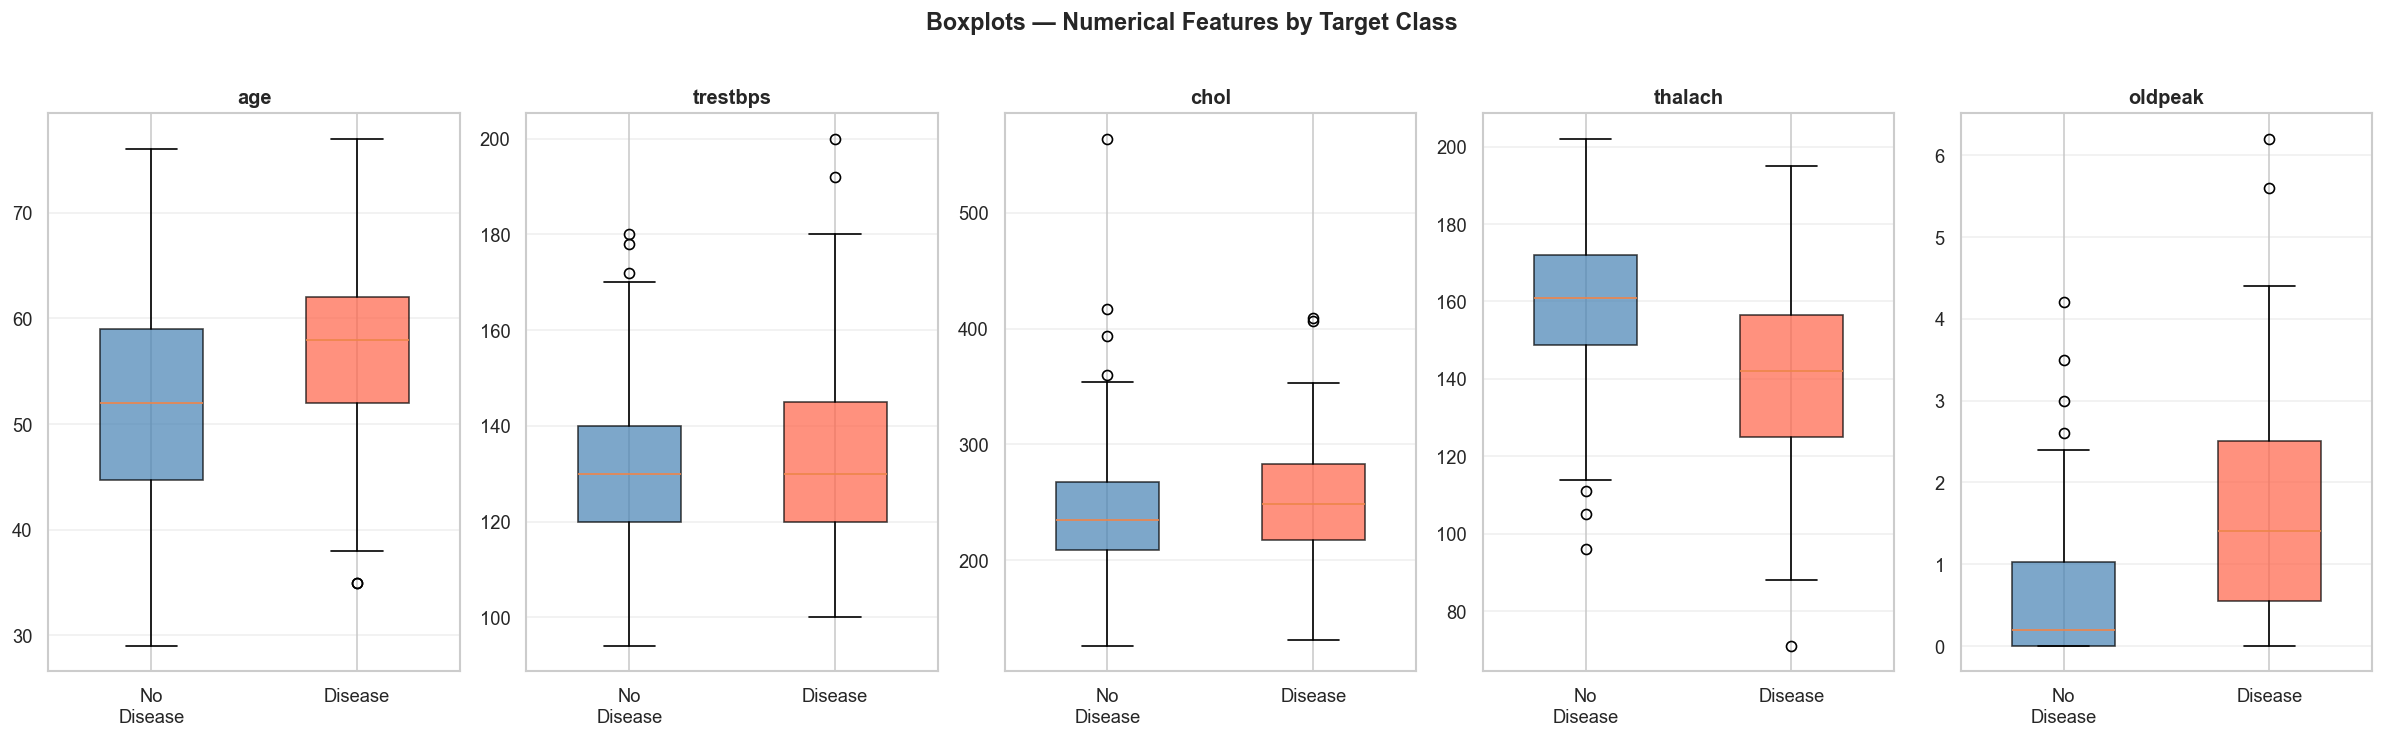

✅ Saved → screenshots/05_boxplots.png


In [18]:
numerical_cols = ["age", "trestbps", "chol", "thalach", "oldpeak"]

fig, axes = plt.subplots(1, 5, figsize=(20, 6))

for i, col in enumerate(numerical_cols):
    # Boxplot split by target class
    data_to_plot = [
        df[df["target"] == 0][col].values,
        df[df["target"] == 1][col].values
    ]
    bp = axes[i].boxplot(
        data_to_plot,
        patch_artist=True,
        labels=["No\nDisease", "Disease"],
        widths=0.5
    )

    # Color boxes
    bp["boxes"][0].set_facecolor("steelblue")
    bp["boxes"][1].set_facecolor("tomato")
    for box in bp["boxes"]:
        box.set_alpha(0.7)

    axes[i].set_title(
        col, fontsize=12, fontweight="bold"
    )
    axes[i].grid(axis="y", alpha=0.3)

plt.suptitle(
    "Boxplots — Numerical Features by Target Class",
    fontsize=14, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig(
    "../screenshots/05_boxplots.png",
    bbox_inches="tight", dpi=150
)
plt.show()
print("✅ Saved → screenshots/05_boxplots.png")

#EDA Summary

In [19]:
print("=" * 55)
print("  EDA SUMMARY — KEY OBSERVATIONS")
print("=" * 55)

observations = [
    "Dataset has 303 patients and 14 features",
    "No missing values after cleaning",
    "Target is balanced: 54.5% Disease, 45.5% No Disease",
    "Age range: 29-77 years, Mean ~54 years",
    "thalach (max heart rate) is LOWER in disease patients",
    "oldpeak (ST depression) is HIGHER in disease patients",
    "cp=3 (asymptomatic chest pain) strongly linked to disease",
    "ca (vessels coloured) increases with disease presence",
    "thal=2 (fixed defect) strongly associated with disease",
    "chol shows outliers but kept for model learning",
]

for i, obs in enumerate(observations, 1):
    print(f"  {i:>2}. {obs}")

print("=" * 55)

# Verify all screenshots saved
print("\n📁 Screenshots saved:")
for f in sorted(os.listdir("../screenshots")):
    size = os.path.getsize(f"../screenshots/{f}")
    print(f"   ✅  {f}  ({size:,} bytes)")

  EDA SUMMARY — KEY OBSERVATIONS
   1. Dataset has 303 patients and 14 features
   2. No missing values after cleaning
   3. Target is balanced: 54.5% Disease, 45.5% No Disease
   4. Age range: 29-77 years, Mean ~54 years
   5. thalach (max heart rate) is LOWER in disease patients
   6. oldpeak (ST depression) is HIGHER in disease patients
   7. cp=3 (asymptomatic chest pain) strongly linked to disease
   8. ca (vessels coloured) increases with disease presence
   9. thal=2 (fixed defect) strongly associated with disease
  10. chol shows outliers but kept for model learning

📁 Screenshots saved:
   ✅  01_class_balance.png  (94,339 bytes)
   ✅  02_numerical_distributions.png  (172,908 bytes)
   ✅  03_categorical_distributions.png  (147,584 bytes)
   ✅  04_correlation_heatmap.png  (163,583 bytes)
   ✅  05_boxplots.png  (91,022 bytes)
